# 📘 Comprehensive Guide to Polynomial Regression

## Table of Contents
1. [Introduction & Intuition](#1-introduction--intuition)
2. [Mathematical Formulation](#2-mathematical-formulation)
3. [The Problem with Linear Regression](#3-the-problem-with-linear-regression)
4. [PolynomialFeatures in Scikit-Learn](#4-polynomialfeatures-in-scikit-learn)
5. [Underfitting vs Overfitting (The Degree Dilemma)](#5-underfitting-vs-overfitting-the-degree-dilemma)
6. [Best Practice: Using Pipelines](#6-best-practice-using-pipelines)
7. [3D Polynomial Regression](#7-3d-polynomial-regression)
8. [Summary & Interview Questions](#8-summary--interview-questions)

---

## 1. Introduction & Intuition

Simple Linear Regression works wonderfully when there is a straight-line relationship between the features and the target variable. However, real-world data is rarely that simple. Often, data curves, dips, and peaks. If we try to fit a straight line to curved data, we will suffer from severe underfitting (high bias).

**What is Polynomial Regression?**

**Polynomial Regression** is a technique that allows us to fit a non-linear curve to the data while still using the standard Linear Regression algorithm under the hood.
Polynomial Regression is a form of regression analysis in which the relationship between the independent variable $X$ and the dependent variable $y$ is modeled as an $n^{th}$ degree polynomial. 

**Why do we need it?**

Linear Regression assumes a straight-line relationship ($y = mx + c$). However, real-world data is rarely perfectly linear. If we try to fit a straight line to curved data, the model will perform poorly (Underfitting). Polynomial Regression solves this by **mapping the original features into a higher-dimensional space** using polynomial combinations, allowing a linear algorithm to fit non-linear boundaries.

```mermaid
graph TD
    A[Real World Data] --> B{Is it Linear?}
    B -->|Yes| C[Simple Linear Regression]
    B -->|No| D[Polynomial Regression]
    D --> E[Create Polynomial Features: X, X^2, X^3...]
    E --> F[Apply Linear Regression on New Features]
    F --> G[Non-Linear Decision Boundary]
    
    style D fill:#f9d71c
    style G fill:#c8e6c9
```

---


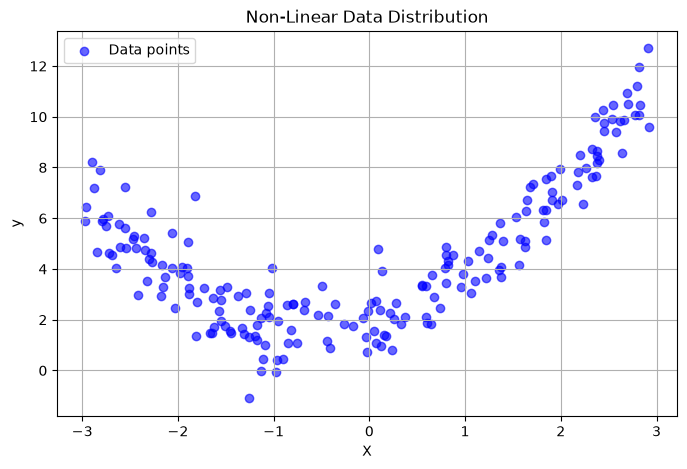

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. Generate Non-Linear Data
np.random.seed(42)
X = 6 * np.random.rand(200, 1) - 3  # Features between -3 and 3
# True relationship: y = 0.8x^2 + 0.9x + 2 + noise
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1) 

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.6, label='Data points')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Non-Linear Data Distribution')
plt.legend()
plt.grid(True)
plt.show()


## 2. Mathematical Formulation

The beauty of Polynomial Regression is that it is fundamentally just Linear Regression applied to transformed data.
- **Simple Linear Equation**: $y = w_1x + b$
- **Polynomial Equation (Degree 2)**: $y = w_1x + w_2x^2 + b$

Notice that the equation is non-linear with respect to the input $x$ (because $x$ is squared), but it is perfectly **linear with respect to the weights ($w_1, w_2$)**. Because of this, we can mathematically pretend that $x^2$ is just a brand-new, separate feature.

```mermaid
graph TD
    A[Raw Feature: X] --> B[PolynomialFeatures]
    B --> C[Degree 0: X^0 = 1<br>Intercept]
    B --> D[Degree 1: X^1 = X<br>Original]
    B --> E[Degree 2: X^2<br>Squared]
    C --> F[Concatenate into New Matrix X']
    D --> F
    E --> F
    F --> G[Apply Standard Linear Regression on X']
    G --> H[Output Model:<br>y = b + w1X + w2X^2]
    
    style A fill:#f9f,stroke:#333,stroke-width:2px
    style F fill:#bbf,stroke:#333,stroke-width:2px
    style H fill:#dfd,stroke:#333,stroke-width:2px
```

---

## 3. The Problem with Linear Regression

What happens if we blindly apply Simple Linear Regression to our curved data? The model will draw a straight line through the middle of the parabola, resulting in massive errors and a very low $R^2$ score. This is called **Underfitting (High Bias)**.

---


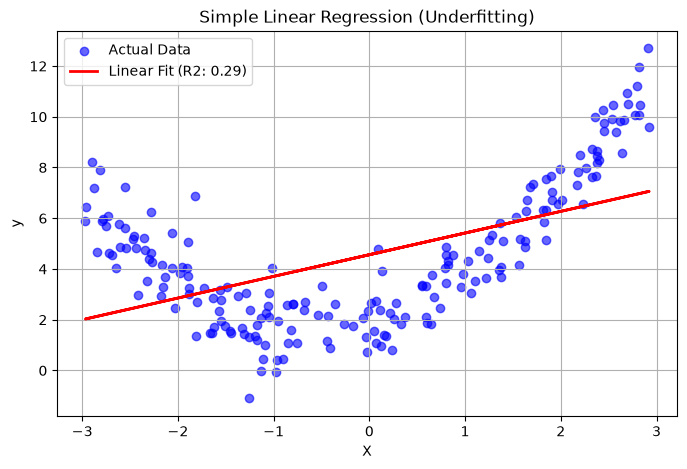

R2 Score for Linear Regression: 0.2891


In [58]:
# 2. Apply Simple Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X, y)

y_pred_linear = lin_reg.predict(X)
r2_linear = r2_score(y, y_pred_linear)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.6, label='Actual Data')
plt.plot(X, y_pred_linear, color='red', linewidth=2, label=f'Linear Fit (R2: {r2_linear:.2f})')
plt.title('Simple Linear Regression (Underfitting)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

print(f"R2 Score for Linear Regression: {r2_linear:.4f}")


## 4. PolynomialFeatures in Scikit-Learn

To fix the underfitting, we use Scikit-Learn's `PolynomialFeatures` to transform our 1D array $X$ into a 2D matrix containing $X$ and $X^2$.


Original X shape: (200, 1)
Polynomial X shape: (200, 2)
First row transformation: [-0.75275929] -> [-0.75275929  0.56664654]


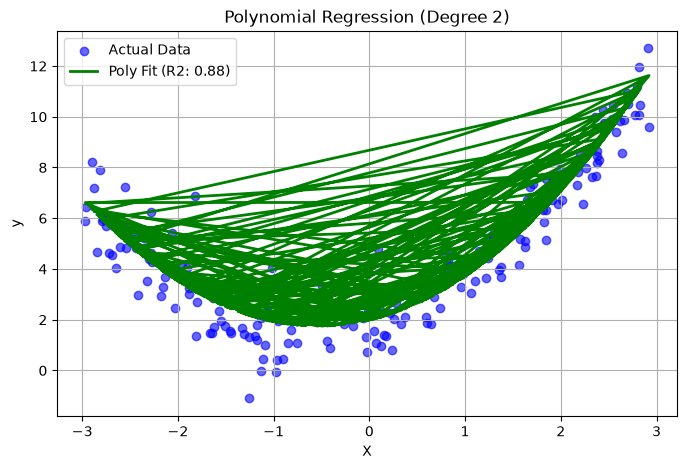


Coefficients: [[0.8880272 0.8255008]]
Intercept: [1.98659698]


In [59]:
from sklearn.preprocessing import PolynomialFeatures

# 3. Transform Features (Degree = 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

print(f"Original X shape: {X.shape}")
print(f"Polynomial X shape: {X_poly.shape}")
print(f"First row transformation: {X[0]} -> {X_poly[0]}")

# 4. Fit Linear Regression on Polynomial Features
poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)

y_pred_poly = poly_reg.predict(X_poly)
r2_poly = r2_score(y, y_pred_poly)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.6, label='Actual Data')
plt.plot(X, y_pred_poly, color='green', linewidth=2, label=f'Poly Fit (R2: {r2_poly:.2f})')
plt.title('Polynomial Regression (Degree 2)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

print(f"\nCoefficients: {poly_reg.coef_}")
print(f"Intercept: {poly_reg.intercept_}")


## 5. Underfitting vs Overfitting (The Degree Dilemma)

Choosing the `degree` hyperparameter is the most critical part of Polynomial Regression.
- **Degree 1**: Underfitting (High Bias). Cannot capture the curve.
- **Degree 2**: Good Fit. Captures the true underlying parabolic trend.
- **Degree 350**: Overfitting (High Variance). The model memorizes the noise and creates wild oscillations.

```mermaid
graph TD
    A[Model Complexity] --> B{Degree of Polynomial}
    B -->|Low Degree e.g., 1| C[Underfitting]
    C --> C1[High Bias]
    C --> C2[Poor Train & Test Accuracy]
    
    B -->|Optimal Degree e.g., 2| D[Good Fit]
    D --> D1[Low Bias, Low Variance]
    D --> D2[Excellent Generalization]
    
    B -->|High Degree e.g., 350| E[Overfitting]
    E --> E1[High Variance]
    E --> E2[Perfect Train, Terrible Test Accuracy]
```


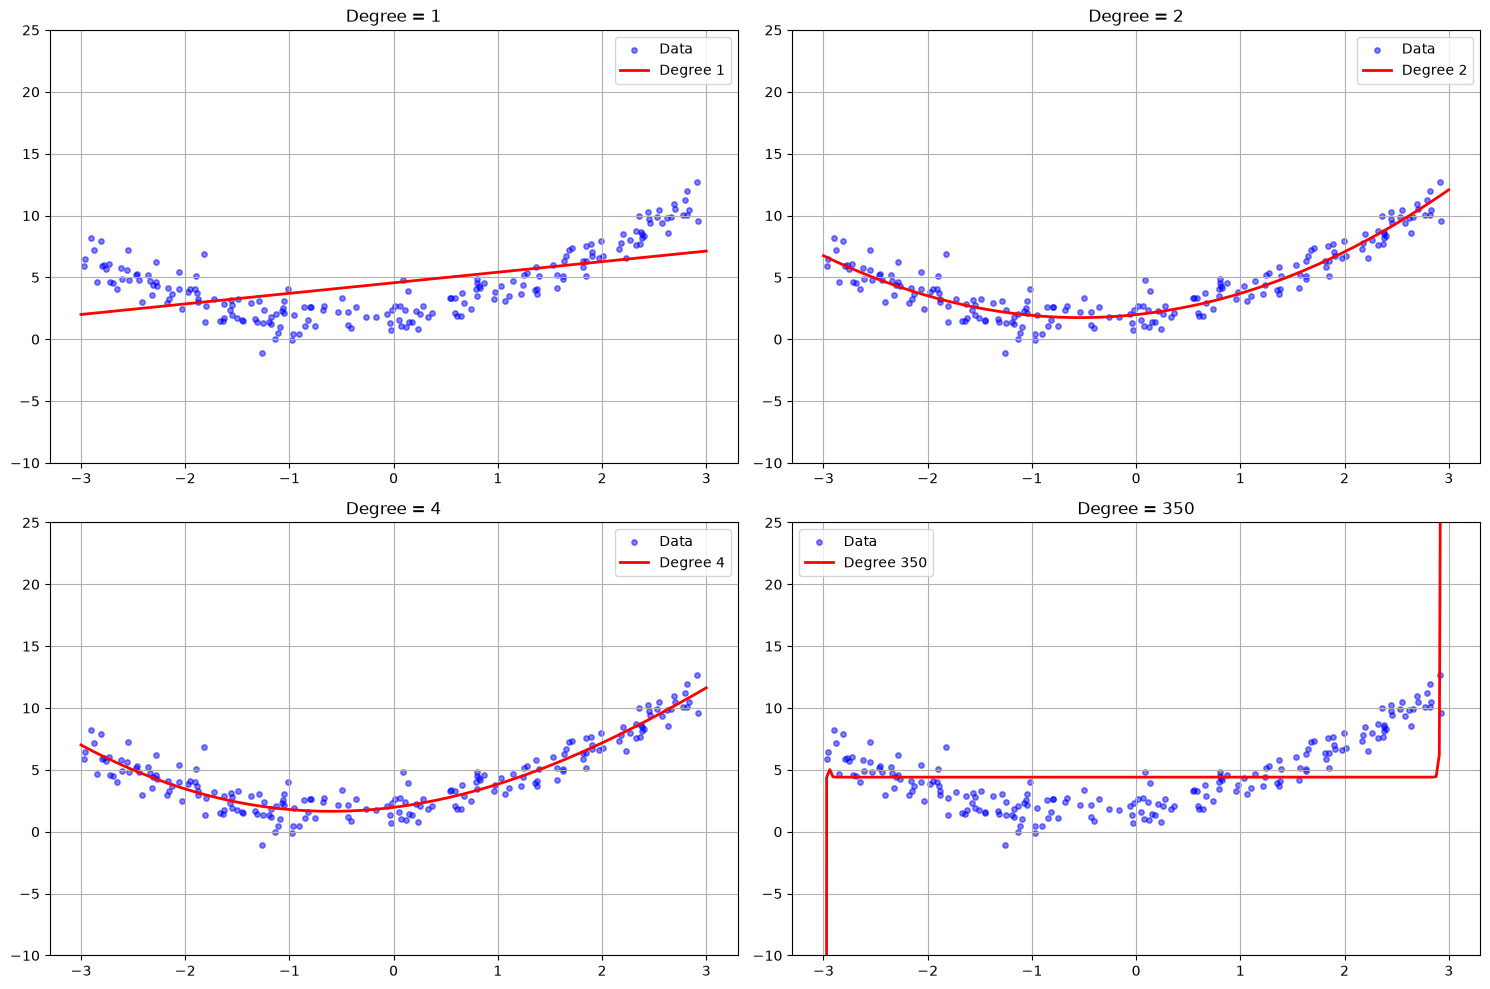

In [60]:
# Visualizing different degrees
plt.figure(figsize=(15, 10))
degrees = [1, 2, 4, 350]

# Create smooth line for plotting
X_plot = np.linspace(-3, 3, 200).reshape(-1, 1)

for i, degree in enumerate(degrees):
    plt.subplot(2, 2, i+1)
    plt.scatter(X, y, color='blue', alpha=0.5, s=15, label='Data')
    
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_plot_poly = poly.fit_transform(X_plot)
    X_train_poly = poly.fit_transform(X)
    
    lin_reg = LinearRegression()
    lin_reg.fit(X_train_poly, y)
    
    y_plot_pred = lin_reg.predict(X_plot_poly)
    
    plt.plot(X_plot, y_plot_pred, color='red', linewidth=2, label=f'Degree {degree}')
    plt.title(f'Degree = {degree}')
    plt.ylim(-10, 25)
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()


## 6. Best Practice: Using Pipelines

When using Polynomial Features, the values of $X^2$ or $X^{10}$ can become **massive**. This causes numerical instability and makes Gradient Descent converge very slowly. 
**Solution**: Always scale your data! We use Scikit-Learn's `Pipeline` to chain `PolynomialFeatures`, `StandardScaler`, and `LinearRegression` seamlessly.

---


In [61]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Create a Pipeline
pipeline = Pipeline([
    ("poly_features", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("lin_reg", LinearRegression())
])

# Fit and Predict in one step
pipeline.fit(X, y)
y_pred_pipeline = pipeline.predict(X)

print(f"Pipeline R2 Score: {r2_score(y, y_pred_pipeline):.4f}")
print(f"Scaled Coefficients: {pipeline.named_steps['lin_reg'].coef_}")


Pipeline R2 Score: 0.8818
Scaled Coefficients: [[1.56729667 2.16008301]]


## 7. 3D Polynomial Regression

Polynomial regression isn't limited to 2D curves. We can extend it to multiple features ($X_1, X_2$) to create **3D surfaces**. 
The equation becomes: $y = \theta_0 + \theta_1 X_1 + \theta_2 X_2 + \theta_3 X_1^2 + \theta_4 X_2^2 + \theta_5 X_1 X_2$

*Note: As seen in the notebook, increasing the degree for multiple features causes **Feature Explosion**. E.g., 2 features with degree 30 results in 496 features!*

---


In [62]:
import plotly.graph_objects as go

# 1. Generate 3D Data
np.random.seed(42)
x1 = 7 * np.random.rand(100, 1) - 2.8
x2 = 7 * np.random.rand(100, 1) - 2.8
# True surface: z = x1^2 + x2^2 + 0.2*x1 + 0.2*x2 + 0.1*x1*x2 + 2 + noise
z = x1**2 + x2**2 + 0.2*x1 + 0.2*x2 + 0.1*x1*x2 + 2 + np.random.randn(100, 1)

X_multi = np.hstack((x1, x2))

# 2. Fit Polynomial Regression
poly_3d = PolynomialFeatures(degree=2, include_bias=False)
X_multi_poly = poly_3d.fit_transform(X_multi)

lin_reg_3d = LinearRegression()
lin_reg_3d.fit(X_multi_poly, z)

# 3. Create a Meshgrid for Surface Plotting
x1_range = np.linspace(x1.min(), x1.max(), 20)
x2_range = np.linspace(x2.min(), x2.max(), 20)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)

# Flatten grid to predict, then reshape back to 2D
grid_flat = np.c_[x1_grid.ravel(), x2_grid.ravel()]
grid_poly = poly_3d.transform(grid_flat)
z_grid = lin_reg_3d.predict(grid_poly).reshape(x1_grid.shape)

# 4. Plotly 3D Visualization
fig = go.Figure(data=[
    go.Surface(x=x1_grid, y=x2_grid, z=z_grid, colorscale='Viridis', opacity=0.8, name='Predicted Surface'),
    go.Scatter3d(x=x1.ravel(), y=x2.ravel(), z=z.ravel(), mode='markers', 
                 marker=dict(size=4, color='red', opacity=0.8), name='Actual Data')
])

fig.update_layout(title='3D Polynomial Regression Surface',
                  scene=dict(xaxis_title='X1', yaxis_title='X2', zaxis_title='Z'),
                  margin=dict(r=20, b=10, l=10, t=40))
fig.show()


## 8. Summary & Interview Questions

### Summary Table
| Concept | Description |
| :--- | :--- |
| **Core Idea** | Maps non-linear data into a higher-dimensional space to fit a linear model. |
| **Algorithm** | It is still **Linear Regression**, just with engineered features. |
| **Hyperparameter** | `degree` (controls model complexity). |
| **Pros** | Can model complex non-linear relationships easily. |
| **Cons** | Prone to overfitting; requires feature scaling; feature explosion for high dimensions. |

### 🎯 Top Interview Questions

**Q1: Is Polynomial Regression a new algorithm?**
> **Ans:** No. It is exactly the same as Multiple Linear Regression. The only difference is the preprocessing step where we create new features by raising existing features to a power. The underlying math (Ordinary Least Squares or Gradient Descent) remains identical.

**Q2: What happens if we increase the degree of the polynomial to infinity?**
> **Ans:** The model will perfectly memorize the training data (including the noise), resulting in 0 training error but catastrophic test error. This is the extreme case of **Overfitting (High Variance)**.

**Q3: Why do we need `StandardScaler` in a Polynomial Regression Pipeline?**
> **Ans:** If $X$ ranges from 1 to 10, $X^2$ ranges from 1 to 100, and $X^5$ ranges from 1 to 100,000. This massive difference in scales causes the loss function contour to become highly elongated, making Gradient Descent oscillate and converge extremely slowly. Scaling brings all polynomial features to the same magnitude.

**Q4: How do you choose the optimal `degree`?**
> **Ans:** We use **Cross-Validation** and plot **Learning Curves** or **Validation Curves**. You test various degrees on a validation set and monitor the validation error. The error will drop as degree increases, but eventually, the validation error will explode upwards while the training error continues to drop to zero. The lowest point on the validation error curve represents the optimal degree. We select the degree that minimizes the validation error without causing the training error to drop to zero prematurely.

**Q5: Is Polynomial Regression a linear or non-linear model?**
> **Ans:** It is a **Linear model**. The word "Linear" refers to the model's parameters (the weights). The equation $y = w_1x_1 + w_2x_2 + b$ is a linear combination of weights. We just artificially feed it $x_1=X$ and $x_2=X^2$. The algorithm itself is identical to standard Multi-Linear Regression.

**Q6: Why is feature scaling (StandardScaler) important for Polynomial Regression?**
> **Ans:** When you raise numbers to high powers (e.g., $X^{10}$), the values explode exponentially. If $X=10$, then $X^{10} = 10,000,000,000$. This creates an extreme disparity in the scale of your features, which severely disrupts the math inside the optimization algorithms (like Gradient Descent), preventing convergence.

**Common Mistakes to Avoid:**
1. **Forgetting to transform the test set:** You must apply the exact same PolynomialFeatures transformation to your test set before calling model.predict().
2. **Extrapolation:** Polynomial models are notoriously bad at predicting values outside the range of the training data. A degree-5 curve might look perfect between $X=[-3, 3]$, but at $X=4$, it might shoot to infinity.

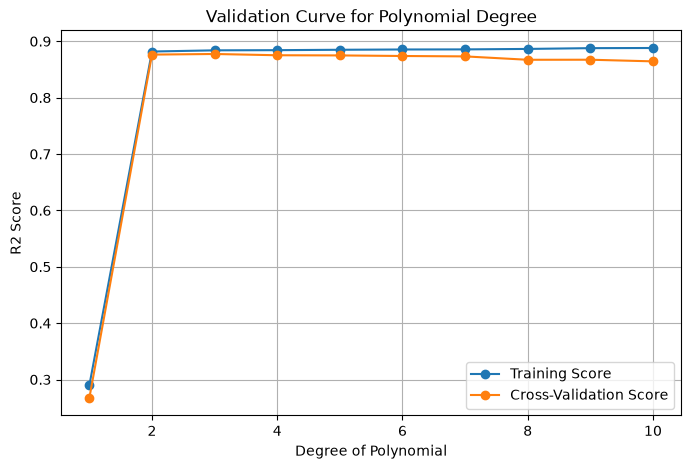

In [63]:
# Practice Exercise: Learning Curve
from sklearn.model_selection import validation_curve

degrees = np.arange(1, 11)
train_scores, test_scores = validation_curve(
    Pipeline([("poly", PolynomialFeatures(include_bias=False)), ("scaler", StandardScaler()), ("model", LinearRegression())]),
    X, y, param_name="poly__degree", param_range=degrees,
    cv=5, scoring="r2"
)

plt.figure(figsize=(8, 5))
plt.plot(degrees, train_scores.mean(axis=1), label='Training Score', marker='o')
plt.plot(degrees, test_scores.mean(axis=1), label='Cross-Validation Score', marker='o')
plt.title('Validation Curve for Polynomial Degree')
plt.xlabel('Degree of Polynomial')
plt.ylabel('R2 Score')
plt.legend()
plt.grid(True)
plt.show()

## Example

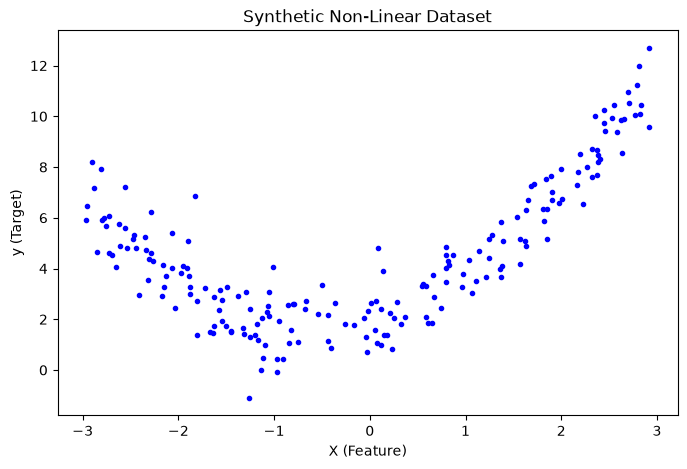

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. Generate Non-Linear Data
np.random.seed(42)
X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Plot the data
plt.figure(figsize=(8, 5))
plt.plot(X, y, 'b.')
plt.xlabel("X (Feature)")
plt.ylabel("y (Target)")
plt.title("Synthetic Non-Linear Dataset")
plt.show()

Linear Regression R2 Score: 0.3445


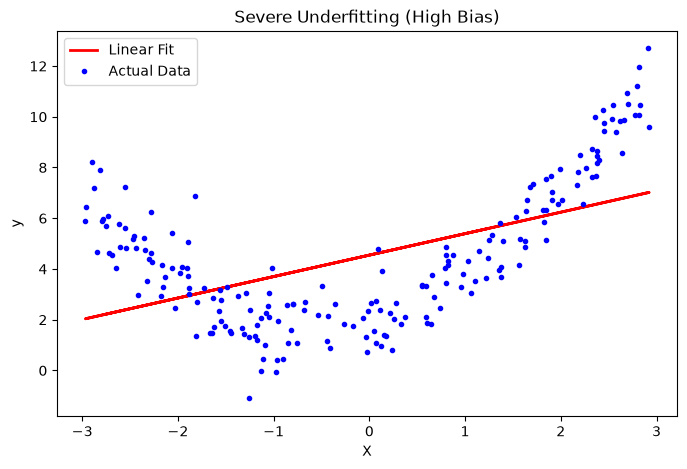

In [65]:
# Apply Standard Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict and Score
y_pred_lr = lr.predict(X_test)
print(f"Linear Regression R2 Score: {r2_score(y_test, y_pred_lr):.4f}")

# Visualize the Underfit
plt.figure(figsize=(8, 5))
plt.plot(X_train, lr.predict(X_train), color='red', linewidth=2, label='Linear Fit')
plt.plot(X, y, "b.", label='Actual Data')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Severe Underfitting (High Bias)")
plt.show()

In [66]:
from sklearn.preprocessing import PolynomialFeatures

# Transform the features
# include_bias=True automatically adds a column of 1s for the y-intercept
poly = PolynomialFeatures(degree=2, include_bias=True)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

# Let's inspect the transformation
print(f"Original X_train[0]: \n{X_train[0]}")
print(f"Transformed X_train_trans[0] (1, x, x^2): \n{X_train_trans[0]}\n")

# Fit Linear Regression to the TRANSFORMED data
lr_poly = LinearRegression()
lr_poly.fit(X_train_trans, y_train)

# Predict and Evaluate
y_pred_poly = lr_poly.predict(X_test_trans)
print(f"Polynomial Regression R2 Score: {r2_score(y_test, y_pred_poly):.4f}")
print(f"Coefficients: {lr_poly.coef_}")
print(f"Intercept: {lr_poly.intercept_}")

Original X_train[0]: 
[1.21811375]
Transformed X_train_trans[0] (1, x, x^2): 
[1.         1.21811375 1.48380112]

Polynomial Regression R2 Score: 0.8414
Coefficients: [[0.         0.87874406 0.83625305]]
Intercept: [1.96595528]


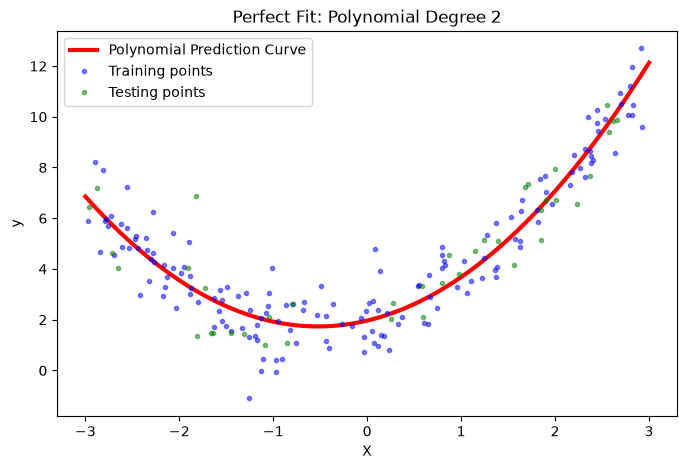

In [67]:
# Generate 200 evenly spaced points from -3 to 3
X_new = np.linspace(-3, 3, 200).reshape(200, 1)

# Transform these points to polynomial features
X_new_poly = poly.transform(X_new)

# Predict
y_new = lr_poly.predict(X_new_poly)

# Visualize
plt.figure(figsize=(8, 5))
plt.plot(X_new, y_new, "r-", linewidth=3, label="Polynomial Prediction Curve")
plt.plot(X_train, y_train, "b.", alpha=0.5, label='Training points')
plt.plot(X_test, y_test, "g.", alpha=0.5, label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.title("Perfect Fit: Polynomial Degree 2")
plt.legend()
plt.show()

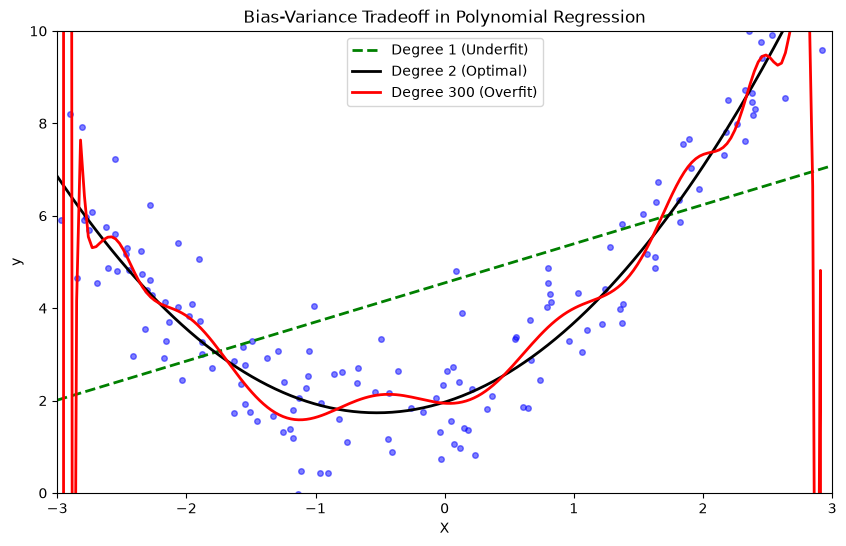

In [68]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def plot_polynomial_regression(degree, style, label):
    # Pipeline: Transform -> Scale -> Linear Regression
    poly_pipeline = Pipeline([
            ("poly_features", PolynomialFeatures(degree=degree, include_bias=False)),
            ("std_scaler", StandardScaler()), # Scaling is crucial for high degrees to avoid exploding numbers
            ("lin_reg", LinearRegression()),
        ])
    
    poly_pipeline.fit(X_train, y_train)
    
    # Predict on continuous space for smooth drawing
    y_newbig = poly_pipeline.predict(X_new)
    plt.plot(X_new, y_newbig, style, label=label, linewidth=2)

plt.figure(figsize=(10, 6))
plt.plot(X_train, y_train, "b.", alpha=0.5, markersize=8)

# Plot different degrees
plot_polynomial_regression(1, "g--", "Degree 1 (Underfit)")
plot_polynomial_regression(2, "k-", "Degree 2 (Optimal)")
plot_polynomial_regression(300, "r-", "Degree 300 (Overfit)")

plt.axis([-3, 3, 0, 10])
plt.legend(loc="upper center")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Bias-Variance Tradeoff in Polynomial Regression")
plt.show()

In [69]:
import matplotlib.animation as animation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X, y, color='blue', alpha=0.4)
line, = ax.plot([], [], color='red', lw=3)
title = ax.set_title('')

ax.set_xlim(-3, 3)
ax.set_ylim(0, 10)
ax.set_xlabel("X")
ax.set_ylabel("y")

# Continuous X for plotting smooth lines
X_plot = np.linspace(-3, 3, 100).reshape(-1, 1)

def animate(degree):
    if degree == 0: degree = 1 # Avoid degree 0 for visual clarity
    
    # Build and fit pipeline
    model = Pipeline([
        ("poly_features", PolynomialFeatures(degree=degree, include_bias=False)),
        ("std_scaler", StandardScaler()),
        ("lin_reg", LinearRegression()),
    ])
    
    model.fit(X_train, y_train)
    y_plot = model.predict(X_plot)
    
    line.set_data(X_plot, y_plot)
    title.set_text(f'Polynomial Regression | Flexibility (Degree): {degree}')
    return line, title

# Generate animation (Frames 1 through 15)
anim = animation.FuncAnimation(fig, animate, frames=range(1, 16), interval=600, blit=True)

# Prevent the static plot from rendering above the animation
plt.close(fig)

# Display the animation in the notebook (Uncomment when running in Colab/Jupyter)
# HTML(anim.to_jshtml())